In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("student_performance.csv")

df.head()

Saving student_performance.csv to student_performance.csv


,Study_Hours,Attendance,Assignments_Completed,Previous_Score,Final_Marks
0,4.6,52.0,2,46.1,43.2
1,7.6,71.8,8,36.3,66.8
2,6.6,52.0,9,71.2,70.0
3,8.4,91.7,3,40.7,59.2
4,6.9,91.0,5,35.8,61.5


In [ ]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours            150 non-null    float64
 1   Attendance             150 non-null    float64
 2   Assignments_Completed  150 non-null    int64  
 3   Previous_Score         150 non-null    float64
 4   Final_Marks            150 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None
Study_Hours              0
Attendance               0
Assignments_Completed    0
Previous_Score           0
Final_Marks              0
dtype: int64


In [ ]:
X = df[['Study_Hours', 'Attendance', 'Assignments_Completed', 'Previous_Score']]

y = df['Final_Marks']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[69.77952514 60.17342401 42.1861013  49.63563467 57.85501164 34.54046045
 51.84116583 67.92081    54.27875878 74.7569857 ]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 3.1419077286657098
MSE : 15.047394727463033
RMSE : 3.879097153650967
R2 Score : 0.9312249748887489


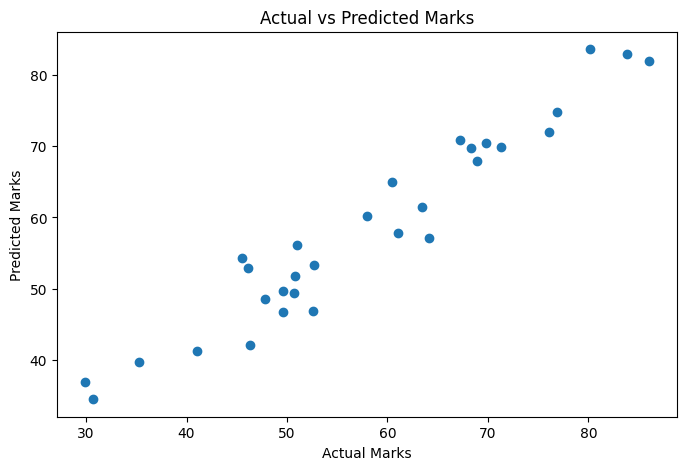

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")

plt.title("Actual vs Predicted Marks")

plt.show()

In [ ]:
corr = df.corr(numeric_only=True)

print(corr)

                       Study_Hours  Attendance  Assignments_Completed  \
Study_Hours               1.000000   -0.071901               0.252908   
Attendance               -0.071901    1.000000              -0.036866   
Assignments_Completed     0.252908   -0.036866               1.000000   
Previous_Score           -0.056759    0.019451              -0.072982   
Final_Marks               0.694203    0.296595               0.605869   

                       Previous_Score  Final_Marks  
Study_Hours                 -0.056759     0.694203  
Attendance                   0.019451     0.296595  
Assignments_Completed       -0.072982     0.605869  
Previous_Score               1.000000     0.302988  
Final_Marks                  0.302988     1.000000  


In [ ]:
new_student = [[6, 85, 7, 75]]

prediction = model.predict(new_student)

print("Predicted Final Marks:", prediction[0])

Predicted Final Marks: 72.34823864915424


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
